# SpliceAI False Positive Predictions within CpG Islands

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [2]:
false_positives = pd.read_csv("../data/SpliceAI_CpGIsland_FalsePositive_Predictions.csv.gz")

In [3]:
acceptor_fp = false_positives.loc[false_positives["type"] == "acceptor"]
donor_fp = false_positives.loc[false_positives["type"] == "donor"]

In [4]:
def calculate_false_positive_contributions(df):
    intronic_fp = df['All_intronic_FP'].sum()
    cpgisland_fp = df['ROI_FP'].sum()
    control_fp = df['CTRL_FP'].sum()
    denominator = intronic_fp if intronic_fp > 0 else 1

    return {
        "False Positives (CpG)": 100.0 * cpgisland_fp / denominator,
        "False Positives (Control)": 100.0 * control_fp / denominator,
    }

In [5]:
total_false_positives = {
    "Splice Acceptors": int(acceptor_fp['All_intronic_FP'].sum()),
    "Splice Donors": int(donor_fp['All_intronic_FP'].sum()),
}

data = {
    "Splice Acceptors": calculate_false_positive_contributions(acceptor_fp),
    "Splice Donors": calculate_false_positive_contributions(donor_fp),
}

/tmp/ipykernel_151899/988972413.py:41: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


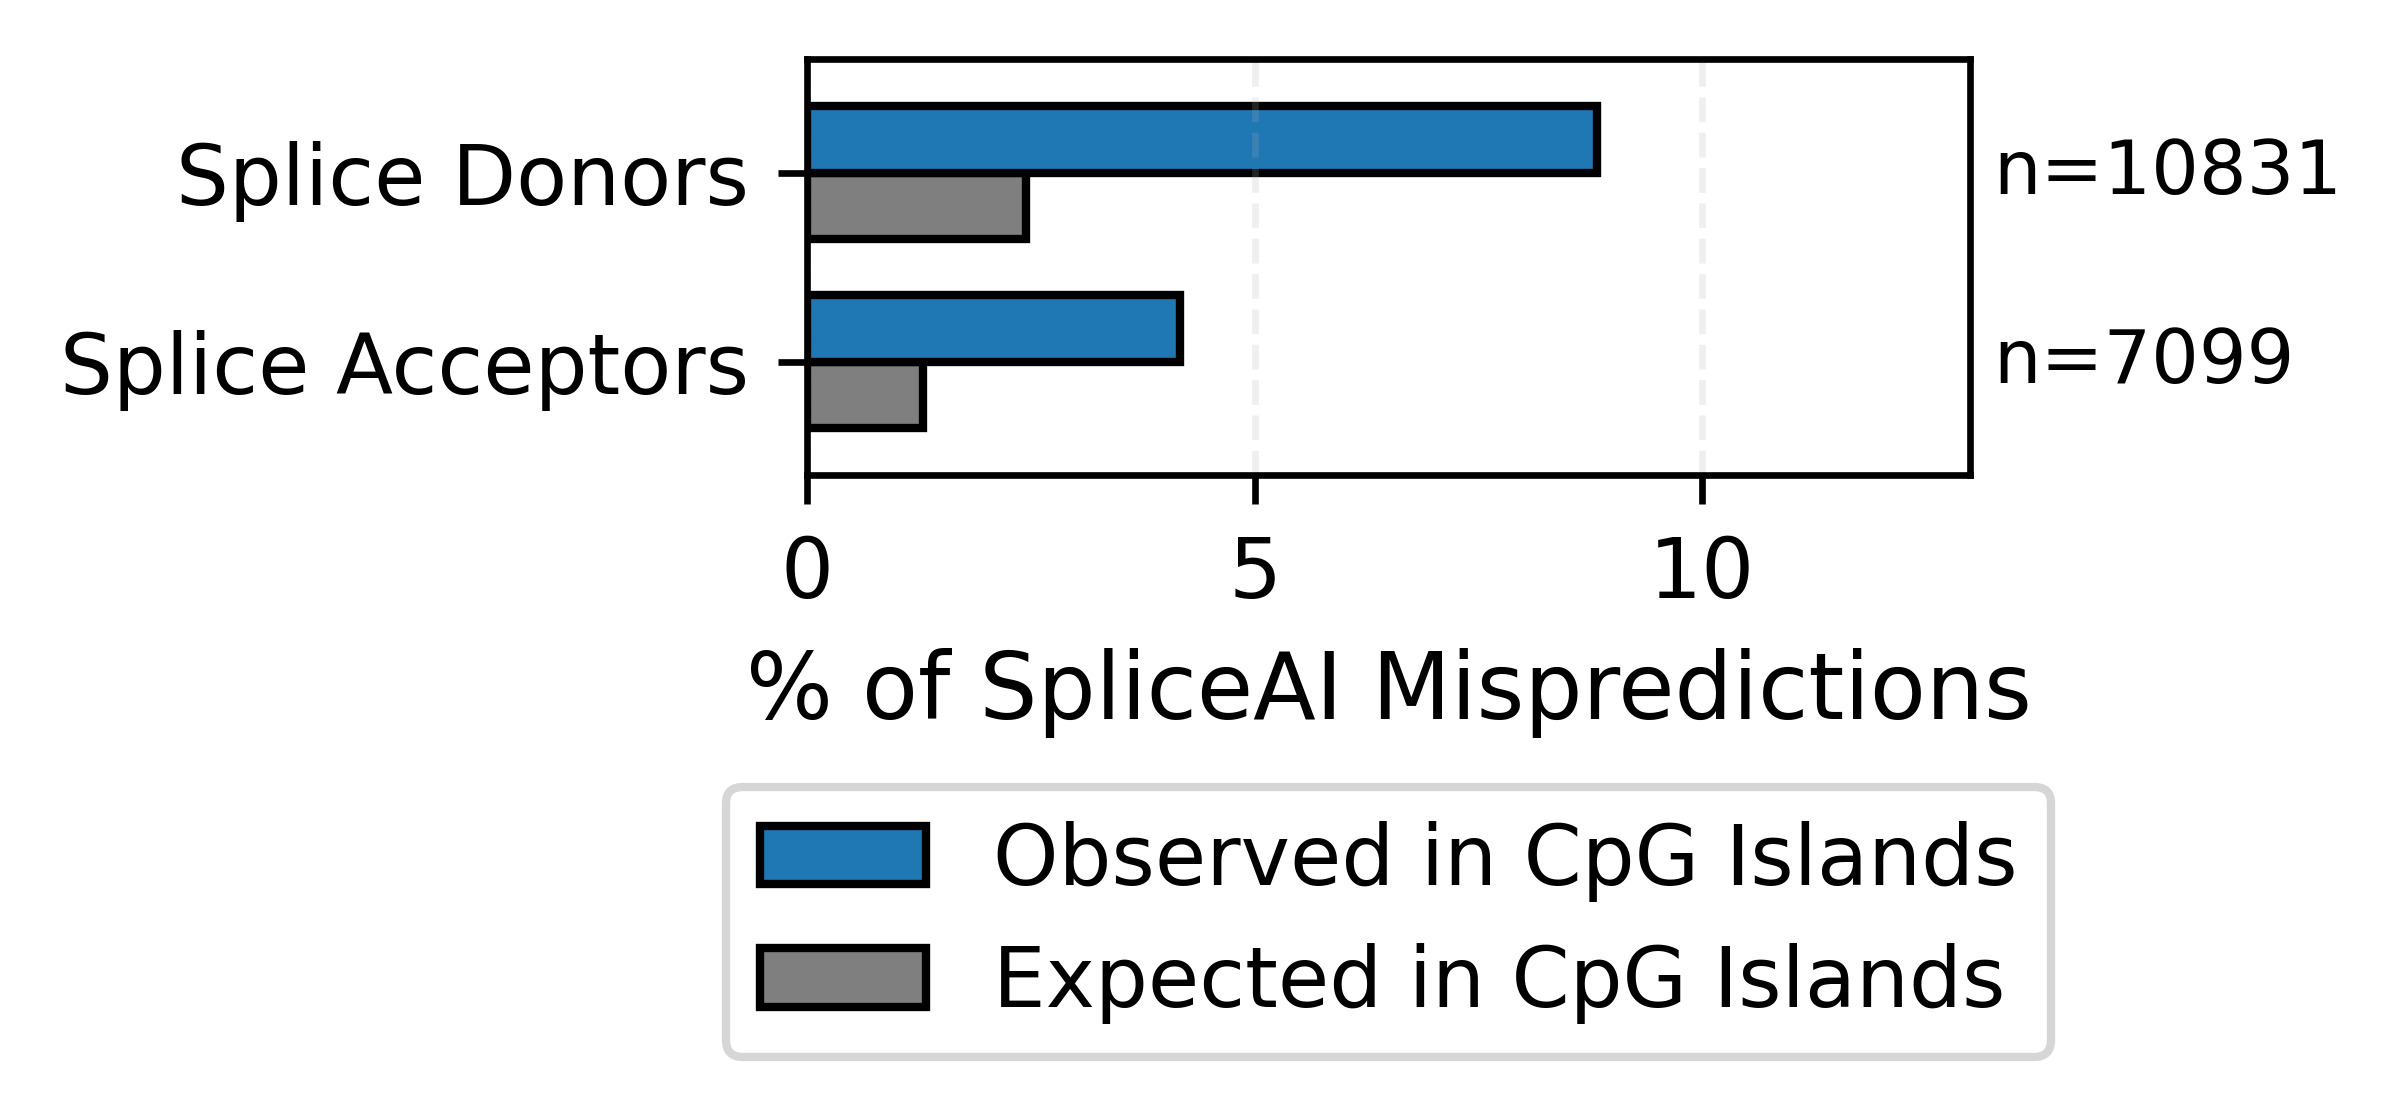

In [6]:
df_plot = pd.DataFrame(data).T
df_plot = df_plot[["False Positives (Control)", "False Positives (CpG)"]]

colors = ["tab:grey", "tab:blue"]
fig, ax = plt.subplots(figsize=(2.5, 0.9), dpi=600)

df_plot.plot(
    kind="barh",
    color=colors,
    edgecolor="black",
    ax=ax,
    width=0.7
)

ax.legend(
    handles=[
        Patch(facecolor="tab:blue", edgecolor="black", label="Observed in CpG Islands"),
        Patch(facecolor="tab:grey", edgecolor="black", label="Expected in CpG Islands"),
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, -1.50),
    ncol=1,
)

ax.set_xlabel("% of SpliceAI Mispredictions", fontsize=11)
ax.set_xlim(0, 13)
ax.set_yticklabels(df_plot.index, fontsize=10, rotation=0)
ax.grid(axis="x", alpha=0.2, linestyle="--")

# Add aligned n= counts to the right of the bars
xlim = ax.get_xlim()
x_text_position = xlim[1] + (xlim[1] - xlim[0]) * 0.02  # Slightly right of plot edge

for i, label in enumerate(df_plot.index):
    count = total_false_positives[label]
    ax.text(x_text_position, i, f"n={count}",
            va='center', ha='left',
            fontsize=9)


fig.tight_layout()
fig.show()